In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import lagrange
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from scipy.interpolate import interp1d
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from scipy.stats import norm
from sklearn.impute import SimpleImputer
from pyecharts.charts import Timeline
from pyecharts.charts import Bar
from pyecharts.globals import ThemeType
from pyecharts import options as opts
from pyecharts.charts import Scatter
from pyecharts.charts import Line
from pyecharts.charts import Boxplot
from sklearn.model_selection import train_test_split,GridSearchCV
from pyecharts.charts import Scatter3D
from pyecharts.charts import Pie,Grid,Page
from pyecharts.charts import Geo, Map
from pyecharts.globals import ChartType
import math
from scipy import stats
from pyecharts.charts import HeatMap,Radar
from pyecharts.charts import WordCloud
from pyecharts.charts import Graph
from pyecharts.charts import Funnel
from pyecharts.charts import Sankey
from pyecharts.charts import Page
from sklearn.metrics import accuracy_score,precision_score,f1_score,recall_score
from sklearn.linear_model import LogisticRegression
from sklearn import svm ,model_selection
from sklearn.ensemble import ExtraTreesClassifier,RandomForestRegressor,AdaBoostClassifier
from sklearn.feature_selection import SelectKBest,f_regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV,cross_val_score, ShuffleSplit,KFold
from sklearn.metrics import mean_squared_error,mean_absolute_error,classification_report,auc,roc_curve,accuracy_score,roc_auc_score,precision_recall_curve,f1_score,accuracy_score,precision_score,recall_score,matthews_corrcoef
from sklearn.tree import DecisionTreeClassifier 
from sklearn.preprocessing import MinMaxScaler,StandardScaler,LabelEncoder
from lightgbm import plot_importance,LGBMClassifier
from scipy import stats
from sklearn.decomposition import PCA
from xgboost import XGBRegressor,plot_importance,XGBClassifier
from sklearn import svm 
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.decomposition import PCA
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity,calculate_kmo
import warnings
import time
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from scipy.stats import pearsonr
from itertools import combinations
import datetime
from dateutil.relativedelta import relativedelta
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error,r2_score
from keras.models import Sequential, load_model
from keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
warnings.filterwarnings('ignore')
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus']=False
sns.set_style('whitegrid',{'font.sans-serif':['simhei','Arial']})

### 数据处理

In [3]:
# 读取数据
data1 = pd.read_csv('安徽.csv')
data2 = pd.read_csv('福建.csv')
data3 = pd.read_csv('甘肃.csv')
data4 = pd.read_csv('广东.csv')
data5 = pd.read_csv('广西.csv')
data6 = pd.read_csv('贵州.csv')
data7 = pd.read_csv('海南.csv')
data8 = pd.read_csv('河北.csv')
data9 = pd.read_csv('河南.csv')
data10 = pd.read_csv('黑龙江.csv')
data11 = pd.read_csv('湖北.csv')
data12 = pd.read_csv('湖南.csv')
data13 = pd.read_csv('吉林.csv')
data14 = pd.read_csv('江苏.csv')
data15 = pd.read_csv('江西.csv')
data16 = pd.read_csv('辽宁.csv')
data17 = pd.read_csv('内蒙古.csv')
data18 = pd.read_csv('宁夏.csv')
data19 = pd.read_csv('青海.csv')
data20 = pd.read_csv('山东.csv')
data21 = pd.read_csv('山西.csv')
data22 = pd.read_csv('陕西.csv')
data23 = pd.read_csv('四川.csv')
data24 = pd.read_csv('西藏.csv')
data25 = pd.read_csv('新疆.csv')
data26 = pd.read_csv('云南.csv')
data27 = pd.read_csv('浙江.csv')
data28 = pd.read_csv('北京.csv')
data29 = pd.read_csv('天津.csv')
data30 = pd.read_csv('上海.csv')
data31 = pd.read_csv('重庆.csv')
data_li=[data1,data2,data3,data4,data5,data6,data7,data8,data9,data10,data11,data12,data13,data14,data15,
         data16,data17,data18,data19,data20,data21,data22,data23,data24,data25,data26,data27,data28,data29,data30,data31]

In [4]:
all_province = ['安徽','福建','甘肃', '广东','广西', '贵州', '海南','河北', '河南', '黑龙江','湖北','湖南',  '吉林', '江苏','江西', '辽宁',
                 '内蒙古','宁夏','青海', '山东', '山西','陕西', '四川', '西藏','新疆','云南','浙江','北京', '天津', '上海','重庆']

#### 去重

In [5]:
# 去重
for i in range(0,len(data_li)):
    data_li[i] = data_li[i].drop_duplicates()
    data_li[i].to_csv(f'{all_province[i]}.csv',index=False)

#### 日期处理

In [6]:
# 将日期数据分割出 年月日
# 部分数据间隔不同 先改成相同 再统一分割
for i in data_li:
    i['日期']=i['日期'].str.replace('-','/')
    i[['年','月','日']]=i['日期'].str.split('/', expand=True)

#### ----------------------------------------------------------数据数据先运行--------------------------------------------------------------------

In [7]:
# 纵向连接所有数据 索引重置
all_data = pd.concat(data_li, axis=0,ignore_index=True)
num_data = all_data[['质量等级','AQI指数','PM2.5','PM10','So2','No2','Co','O3','年','月','日']]
pre_data=all_data.iloc[:, ~all_data.columns.isin(['年','月','日','日期','当天AQI排名','质量等级','省份'])]
#all_data.to_csv("all_data.csv",index=False)

#### 异常值剔除-箱线图

In [98]:
# 异常值检测和处理 
# 用于观察数据除去一些特殊情况的箱线图情况
def detect_outliers(data, columns, threshold=1.5):
    for column in columns:
        q1 = data[column].quantile(0.25)
        q3 = data[column].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - threshold * iqr
        upper_bound = q3 + threshold * iqr
        outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
        print(f"{column} 异常值数量：{len(outliers)}")
        # 将异常值替换为缺失值
        data[column] = data[column].apply(lambda x: np.nan if (x < lower_bound) or (x > upper_bound) else x)
col = ['AQI指数','PM2.5','PM10','So2','No2','Co','O3']
box_data = all_data.copy()
detect_outliers(box_data,col)

AQI指数 异常值数量：6260
PM2.5 异常值数量：7178
PM10 异常值数量：5594
So2 异常值数量：9626
No2 异常值数量：2723
Co 异常值数量：6802
O3 异常值数量：1113


In [99]:
# 各指标 箱线图 看分布
col = ['AQI指数','PM2.5','PM10','So2','No2','Co','O3']
box_data = box_data.dropna(how="any")
box_data=[box_data['AQI指数'].tolist(),box_data['PM2.5'].tolist(),box_data['PM10'].tolist(),box_data['So2'].tolist(),
    box_data['No2'].tolist(),box_data['Co'].tolist(),box_data['O3'].tolist()]
box=Boxplot(init_opts=opts.InitOpts(width='150th',height='450px'))
box.set_global_opts(
        title_opts=opts.TitleOpts(title="各指标箱线图"),
        yaxis_opts=opts.AxisOpts(name="数值"),
        toolbox_opts=opts.ToolboxOpts(is_show=False),
        legend_opts=opts.LegendOpts(orient='vertical')
    )
box.add_xaxis(col)
box.add_yaxis('',box.prepare_data(box_data))
#box.set_global_opts(title_opts=opts.TitleOpts(title='各指标箱线图'),        )
box.render_notebook()

#### 质量等级分布

In [56]:
# 质量等级-柱形+环形
#     .add_yaxis('数量',temp['质量等级'].tolist(),itemstyle_opts=opts.ItemStyleOpts(color='#1E70B2'))
temp=all_data['质量等级'].value_counts().reset_index()
bar=(
    Bar(init_opts=opts.InitOpts(width="600px",height="300px"))
    .add_xaxis(temp['index'].tolist())
    .add_yaxis('数量',temp['质量等级'].tolist())
    .set_global_opts(title_opts=opts.TitleOpts(title='空气质量等级分布柱形图'),
                     legend_opts=opts.LegendOpts(pos_left="30%"))
    
)

pie=(Pie(init_opts=opts.InitOpts(theme='light',width='30px',height='300px'))
    .add('',[list(z) for z in zip(temp['index'].tolist(),temp['质量等级'].tolist())],radius=[35,85],center=[800,300])
    .set_global_opts(title_opts=opts.TitleOpts(title='空气质量等级环图',pos_left='50%'),
                     legend_opts=opts.LegendOpts(orient='vertical',pos_right=40)
                    ,yaxis_opts=opts.AxisOpts(name="数量"))
    .set_series_opts(label_opts=opts.LabelOpts(formatter='{b}:{c} ({d}%)')))

grid=(Grid(init_opts=opts.InitOpts(width='1050px',height='600px')))
grid.add(bar,grid_opts=opts.GridOpts(pos_right="50%"))
grid.add(pie,grid_opts=opts.GridOpts(pos_left="5%"))
grid.render_notebook()

####  质量等级对应指标

In [57]:
# 质量等级对应指标 堆叠柱形
temp=num_data.iloc[:, ~num_data.columns.isin(['年','月','日'])]
temp=temp.groupby('质量等级').mean()
temp['x']=temp.index
#temp['x']=temp['AQI指数'].astype('category')
temp.sort_values('AQI指数',inplace=True)
temp=temp.iloc[:, ~temp.columns.isin(['x'])]
init_opts=opts.InitOpts(width='700px',height='400px')
bar=(
    Bar(init_opts)
    .add_xaxis(temp.index.tolist())
    .add_yaxis('PM10',temp['PM10'].tolist(),stack='stack1',label_opts=opts.LabelOpts(position='insideTop'))
    .add_yaxis('O3',temp['O3'].tolist(),stack='stack1',label_opts=opts.LabelOpts(position='insideTop'))
    .add_yaxis('So2',temp['So2'].tolist(),stack='stack1',label_opts=opts.LabelOpts(position='insideTop'))
    .add_yaxis('PM2.5',temp['PM2.5'].tolist(),stack='stack1',label_opts=opts.LabelOpts(position='insideTop'))
    .add_yaxis('No2',temp['No2'].tolist(),stack='stack1',label_opts=opts.LabelOpts(position='insideTop'))
    .add_yaxis('Co',temp['Co'].tolist(),stack='stack1',label_opts=opts.LabelOpts(position='insideTop'))
    .set_global_opts(title_opts=opts.TitleOpts(title='质量等级-指标'),yaxis_opts=opts.AxisOpts(name="指标均值"),)
    .set_series_opts(label_opts=opts.LabelOpts(is_show=False))
)
bar.render_notebook()

#### 各种质量等级年变化

In [58]:
# 年分类
data2015 = all_data[all_data['年']=="2015"].groupby('质量等级').count()
data2016 = all_data[all_data['年']=="2016"].groupby('质量等级').count()
data2017 = all_data[all_data['年']=="2017"].groupby('质量等级').count()
data2018 = all_data[all_data['年']=="2018"].groupby('质量等级').count()
data2019 = all_data[all_data['年']=="2019"].groupby('质量等级').count()
data2020 = all_data[all_data['年']=="2020"].groupby('质量等级').count()
data2021 = all_data[all_data['年']=="2021"].groupby('质量等级').count()
data2022 = all_data[all_data['年']=="2022"].groupby('质量等级').count()
data2023 = all_data[all_data['年']=="2023"].groupby('质量等级').count()
data2024 = all_data[all_data['年']=="2024"].groupby('质量等级').count()

In [59]:
for i in range(2015,2025):
    s='data'+str(i)
    s=all_data[all_data['年']==str(i)]
    s=s.groupby('质量等级').count()

In [60]:
li1=[]
li2=[]
li3=[]
li4=[]
li5=[]
li6=[]
t=1
for i in [li1,li2,li3,li4,li5,li6]:
    if t==1:
        j=0
    if t ==2:
        j=1
    if t==3:
        j=2
    if t ==4:
        j=3
    if t==5:
        j=4
    if t==6:
        j=5
    i.append(int(data2015.iloc[j,0]))
    i.append(int(data2016.iloc[j,0]))
    i.append(int(data2017.iloc[j,0]))
    i.append(int(data2018.iloc[j,0]))
    i.append(int(data2019.iloc[j,0]))
    i.append(int(data2020.iloc[j,0]))
    i.append(int(data2021.iloc[j,0]))
    i.append(int(data2022.iloc[j,0]))
    i.append(int(data2023.iloc[j,0]))
    i.append(int(data2024.iloc[j,0]))
    t+=1

In [61]:
def line_stack_area():
    line = Line(init_opts=opts.InitOpts(theme='light',width='1000px',height='600px'))
    line.add_xaxis(['2015','2016','2017','2018','2019','2020','2021','2022','2023','2024'])
    line.add_yaxis('严重污染',li1,stack='stack')
    line.add_yaxis('轻度污染',li5,stack='stack')
    line.add_yaxis('中度污染',li2,stack='stack')
    line.add_yaxis('优',li3,stack='stack')
    line.add_yaxis('良',li4,stack='stack')
    line.add_yaxis('重度污染',li6,stack='stack')
    line.set_global_opts(title_opts=opts.TitleOpts(title='质量等级-年变化'),yaxis_opts=opts.AxisOpts(name="数量"))
    
    line.set_series_opts(areastyle_opts=opts.AreaStyleOpts(opacity=0.5))
    return line
chart = line_stack_area()
chart.render_notebook()

#### 质量等级-指标-面积图
temp=num_data.iloc[:, ~num_data.columns.isin(['年','月','日'])]
temp=temp.groupby('质量等级').mean().round(0)

def line_stack_area():
    line = Line(init_opts=opts.InitOpts(theme='light',width='1000px',height='600px'))
    line.add_xaxis(temp.columns.tolist())
    line.add_yaxis('优',temp.loc[' 优'].tolist(),stack='stack')
    line.add_yaxis('良',temp.loc[' 良'].tolist(),stack='stack')
    line.add_yaxis('轻度污染',temp.loc[' 轻度污染'].tolist(),stack='stack')
    line.add_yaxis('中度污染',temp.loc[' 中度污染'].tolist(),stack='stack')
    line.add_yaxis('重度污染',temp.loc[' 重度污染'].tolist(),stack='stack')
    line.add_yaxis('严重污染',temp.loc[' 严重污染'].tolist(),stack='stack')
    line.set_global_opts(title_opts=opts.TitleOpts(title='质量等级-指标'))
    line.set_series_opts(areastyle_opts=opts.AreaStyleOpts(opacity=0.5))

    return line
chart = line_stack_area()
chart.render_notebook()

#### 各指标各年变化

In [62]:
# 年-各个指标
# 时间线轮播多图
# time=data['time']=data.apply(lambda row: str(row['年']) + '年' + str(row['月'])+'月', axis=1).tolist()
temp=num_data.iloc[:, ~num_data.columns.isin(['月','日','质量等级'])]
#temp1=temp.groupby('年').min().round(2)
temp2=temp.groupby('年').mean().round(2)
#temp3=temp.groupby('年').max().round(2)
x_data=temp2.columns.tolist()
time=temp2.index.tolist()
timeline=Timeline()
for i in range(len(time)):
    y_data2=temp2.iloc[i,0:8].tolist()
    y_data2=[str(j) for j in y_data2]
    bar=(
        Bar()
        .add_xaxis(x_data)
        .add_yaxis('平均值',y_data2)
        .set_global_opts(title_opts=opts.TitleOpts('{}各项指标情况'.format(time[i])))
    )
    timeline.add(bar,time[i])
timeline.add_schema(play_interval=1000,is_auto_play=True,symbol='pin')
timeline.render_notebook()

#### AQI年变化

In [63]:
# 年 AQI变化 柱形
temp3=num_data.copy()
counts1 = temp3.groupby('年').agg({'AQI指数': 'mean'})
date = [f'{x}年' for x in range(2015, 2025)]
value1 = [math.ceil(i) for i in counts1['AQI指数']]
bar = (
    Bar(init_opts=opts.InitOpts(width="800px",height="400px"))
    .add_xaxis(date)
    .add_yaxis("AQI",value1)
    .set_global_opts(
        xaxis_opts=opts.AxisOpts(name='年份',name_location='center',name_gap=25),
        title_opts=opts.TitleOpts(title='2015-2024年AQI变化图'),
        yaxis_opts=opts.AxisOpts(name='AQI均值',name_location='center',name_gap=50,
        axislabel_opts=opts.LabelOpts(formatter='{value}')),
        visualmap_opts=opts.VisualMapOpts(
        is_show=True,
        min_=70,
        max_=95,
        range_color=['orange', 'red']),
        legend_opts = opts.LegendOpts(is_show = False)
        )
)
bar.render_notebook()

#### 各季度AQI

In [64]:
# 季度 AQI最大最小值分布 柱形
# 季度
temp1=num_data.copy()
# 季度数据添加
temp1['季度']=0
for i in temp1.index.tolist():
    if temp1['月'][i] in ["01", "02", "03","1","2","3"]:
        temp1['季度'][i]=1
    elif temp1['月'][i] in ["04", "05", "06","4","5","6"]:
        temp1['季度'][i]=2
    elif temp1['月'][i] in ["07", "08", "09","7","8","9"]:
        temp1['季度'][i]=3
    elif temp1['月'][i] in ["10", "11", "12"]:
        temp1['季度'][i]=4

counts1 = temp1[temp1['年']=="2015"].groupby('季度').agg({'AQI指数': 'mean'})
counts2 = temp1[temp1['年']=="2016"].groupby('季度').agg({'AQI指数': 'mean'})
counts3 = temp1[temp1['年']=="2017"].groupby('季度').agg({'AQI指数': 'mean'})
counts4 = temp1[temp1['年']=="2018"].groupby('季度').agg({'AQI指数': 'mean'})
counts5 = temp1[temp1['年']=="2019"].groupby('季度').agg({'AQI指数': 'mean'})
counts6 = temp1[temp1['年']=="2020"].groupby('季度').agg({'AQI指数': 'mean'})
counts7 = temp1[temp1['年']=="2021"].groupby('季度').agg({'AQI指数': 'mean'})
counts8 = temp1[temp1['年']=="2022"].groupby('季度').agg({'AQI指数': 'mean'})
counts9 = temp1[temp1['年']=="2023"].groupby('季度').agg({'AQI指数': 'mean'})
counts10 = temp1[temp1['年']=="2024"].groupby('季度').agg({'AQI指数': 'mean'})
date = [f'{x}季度' for x in range(1, 5)]
value1 = [math.ceil(i) for i in counts1['AQI指数']]
value2 = [math.ceil(i) for i in counts2['AQI指数']]
value3 = [math.ceil(i) for i in counts3['AQI指数']]
value4 = [math.ceil(i) for i in counts4['AQI指数']]
value5 = [math.ceil(i) for i in counts5['AQI指数']]
value6 = [math.ceil(i) for i in counts6['AQI指数']]
value7 = [math.ceil(i) for i in counts7['AQI指数']]
value8 = [math.ceil(i) for i in counts8['AQI指数']]
value9 = [math.ceil(i) for i in counts9['AQI指数']]
value10 = [math.ceil(i) for i in counts10['AQI指数']]
bar=(
    Bar(init_opts=opts.InitOpts(width="1200px",height="400px"))
    .add_xaxis(date)
    .add_yaxis('2015',value1,z=0)
    .add_yaxis('2016',value2,z=0)
    .add_yaxis('2017',value3,z=0)
    .add_yaxis('2018',value4,z=0)
    .add_yaxis('2019',value5,z=0)
    .add_yaxis('2020',value6,z=0)
    .add_yaxis('2021',value7,z=0)
    .add_yaxis('2022',value8,z=0)
    .add_yaxis('2023',value9,z=0)
    .add_yaxis('2024',value10,z=0)
    .set_series_opts(label_opts=opts.LabelOpts(is_show=False),
                     markpoint_opts=opts.MarkPointOpts(data=[opts.MarkPointItem(type_="max", name="最大值"),
                                                             opts.MarkPointItem(type_="min", name="最小值")]))
    .set_global_opts(
        xaxis_opts=opts.AxisOpts(name='季度',name_location='center',name_gap=25),
        yaxis_opts=opts.AxisOpts(name='AQI',name_location='center',name_gap=50,
        axislabel_opts=opts.LabelOpts(formatter='{value}')),
        legend_opts=opts.LegendOpts(pos_right="20%"),
    )
    
)
bar.render_notebook()

#### 各月AQI占比

In [65]:
# 月 AQI
temp=num_data.copy()
num_data['月']=num_data['月'].str.replace('01','1')
num_data['月']=num_data['月'].str.replace('02','2')
num_data['月']=num_data['月'].str.replace('03','3')
num_data['月']=num_data['月'].str.replace('04','4')
num_data['月']=num_data['月'].str.replace('05','5')
num_data['月']=num_data['月'].str.replace('06','6')
num_data['月']=num_data['月'].str.replace('07','7')
num_data['月']=num_data['月'].str.replace('08','8')
num_data['月']=num_data['月'].str.replace('09','9')
counts=temp.groupby('月').agg({'AQI指数': 'mean'})
date = [f'{x}月' for x in range(1, 13)]
pie=(Pie(init_opts=opts.InitOpts(width='810px',height='400px'))
    .add('',[list(z) for z in zip(date,counts['AQI指数'].round(0).tolist())],
         rosetype='radius',radius=[20,100])
    .set_global_opts(title_opts=opts.TitleOpts(title='1-12月AQI均值玫瑰图',pos_right=420),
                    legend_opts=opts.LegendOpts(orient='vertical',pos_right=0))
    .set_series_opts(label_opts=opts.LabelOpts(formatter='{b}:{c} ({d}%)'))
    )
pie.render_notebook()

#### 各省份AQI分布情况

In [66]:
all_province = ['安徽','福建','甘肃', '广东','广西', '贵州', '海南','河北', '河南', '黑龙江','湖北','湖南',  '吉林', '江苏','江西', '辽宁',
                 '内蒙古','宁夏','青海', '山东', '山西','陕西', '四川', '西藏','新疆','云南','浙江','北京', '天津', '上海','重庆']
for i in range(0,len(data_li)):
    data_li[i]['省份']=all_province[i]
temp = pd.concat(data_li, axis=0,ignore_index=True)

In [67]:
ip_data = temp[['省份','AQI指数']]
ip_data_count = ip_data.groupby('省份')['AQI指数'].mean()
df = pd.DataFrame(ip_data_count.rename_axis('ip').reset_index(name='counts'))
# 保留有数据的省份
df = df[df['ip'].isin(all_province)]
province_list = [list(z) for z in zip(df['ip'], df['counts'].astype(int, errors='ignore'))]
# 将省份名字修改为对应省份格式
for i in range(0,len(province_list)):
    if province_list[i][0] == "新疆":
        province_list[i][0] = "新疆维吾尔自治区"
    elif province_list[i][0] == "广西":
        province_list[i][0] = "广西壮族自治区"
    elif province_list[i][0] == "宁夏":
        province_list[i][0] = "宁夏回族自治区"
    elif province_list[i][0] in ["内蒙古","西藏"]:
        province_list[i][0] = province_list[i][0] + "自治区"
    elif province_list[i][0] in ["北京","天津","重庆","上海"]:
        province_list[i][0] = province_list[i][0] + "市"
    else:
        province_list[i][0] = province_list[i][0] + "省"
print(province_list)

[['上海市', 57], ['云南省', 43], ['内蒙古自治区', 71], ['北京市', 76], ['吉林省', 66], ['四川省', 69], ['天津市', 81], ['宁夏回族自治区', 75], ['安徽省', 70], ['山东省', 90], ['山西省', 87], ['广东省', 48], ['广西壮族自治区', 49], ['新疆维吾尔自治区', 88], ['江苏省', 64], ['江西省', 59], ['河北省', 99], ['河南省', 97], ['浙江省', 59], ['海南省', 33], ['湖北省', 71], ['湖南省', 68], ['甘肃省', 78], ['福建省', 43], ['西藏自治区', 43], ['贵州省', 45], ['辽宁省', 71], ['重庆市', 60], ['陕西省', 92], ['青海省', 69], ['黑龙江省', 70]]


In [68]:
# 地图
map = (
    Map(init_opts=opts.InitOpts(width="1000px", height="800px")) #可切换主题
    .set_global_opts(
        title_opts=opts.TitleOpts(title="各省AQI指数地图"),
        visualmap_opts=opts.VisualMapOpts(
            min_=40,
            max_=101,
            range_text = ['AQI指数颜色区间:', ''],  #分区间
            is_piecewise=True,  #定义图例为分段型，默认为连续的图例
            pos_top= "middle",  #分段位置
            pos_left="left",
            orient="vertical",
            split_number=5  #分成10个区间
        )
    )
    .add("AQI",province_list,maptype="china")
    
)
map.render_notebook()

#### 各指标走势

In [102]:
# 各指标年走势
num_data = all_data[['质量等级','AQI指数','PM2.5','PM10','So2','No2','Co','O3','年','月','日']]
temp1=num_data.iloc[:, ~num_data.columns.isin(['月','日','质量等级'])]
scaler = MinMaxScaler(feature_range=(0, 1))
temp1[['PM10','PM2.5', 'Co', 'No2','So2','O3']] = scaler.fit_transform(temp1[['PM10','PM2.5', 'Co', 'No2','So2','O3']])
temp1=temp1.groupby('年').mean().round(2)
line = (
    Line()
    .add_xaxis(temp1.index.tolist())
    .add_yaxis('PM10',temp1['PM10'].tolist())
    .add_yaxis('PM2.5',temp1['PM2.5'].tolist())
    .add_yaxis('No2',temp1['No2'].tolist())
    .add_yaxis('So2',temp1['So2'].tolist())
    .add_yaxis('O3',temp1['O3'].tolist())
    .add_yaxis('Co',temp1['Co'].tolist())
    .set_global_opts(
        title_opts=opts.TitleOpts(title="各指标年走势图"),
        yaxis_opts=opts.AxisOpts(name="指标均值"),
        toolbox_opts=opts.ToolboxOpts(is_show=False)
    )
)
line.render_notebook()

In [103]:
# 月走势
num_data = all_data[['质量等级','AQI指数','PM2.5','PM10','So2','No2','Co','O3','年','月','日']]
num_data['月']=num_data['月'].str.replace('01','1')
num_data['月']=num_data['月'].str.replace('02','2')
num_data['月']=num_data['月'].str.replace('03','3')
num_data['月']=num_data['月'].str.replace('04','4')
num_data['月']=num_data['月'].str.replace('05','5')
num_data['月']=num_data['月'].str.replace('06','6')
num_data['月']=num_data['月'].str.replace('07','7')
num_data['月']=num_data['月'].str.replace('08','8')
num_data['月']=num_data['月'].str.replace('09','9')
temp=num_data.iloc[:, ~num_data.columns.isin(['年','日','质量等级'])]
scaler = MinMaxScaler(feature_range=(0, 1))
temp[['PM10','PM2.5', 'Co', 'No2','So2']] = scaler.fit_transform(temp[['PM10','PM2.5', 'Co', 'No2','So2']])
temp=temp.groupby('月').mean().round(2)
line = (
    Line()
    .add_xaxis(['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12'])
    .add_yaxis('PM10',temp['PM10'].tolist())
    .add_yaxis('PM2.5',temp['PM2.5'].tolist())
    .add_yaxis('No2',temp['No2'].tolist())
    .add_yaxis('So2',temp['So2'].tolist())
    .add_yaxis('Co',temp['Co'].tolist())
    .set_global_opts(
        title_opts=opts.TitleOpts(title="O3以外指标月走势图"),
        yaxis_opts=opts.AxisOpts(name="指标均值"),
        toolbox_opts=opts.ToolboxOpts(is_show=False)
    )
)
line.render_notebook()

In [101]:
line = (
    Line()
    .add_xaxis(['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12'])
    .add_yaxis('O3',temp['O3'].tolist())
    .set_global_opts(
        title_opts=opts.TitleOpts(title="O3月走势图"),
        yaxis_opts=opts.AxisOpts(name="指标均值"),
        toolbox_opts=opts.ToolboxOpts(is_show=False)
    )
)
line.render_notebook()

#### 直辖市污染物雷达图

In [71]:
np.round(data28['PM2.5'].mean(),2)

46.29

In [72]:
l1=[]
l2=[]
l3=[]
l4=[]
t=1
for j in [l1,l2,l3,l4]:
    for i in ['PM2.5','PM10','So2','No2','Co','O3']:
        if t==1:
            l1.append(np.round(data28[i].mean(),2))
        if t==2:
            l2.append(np.round(data29[i].mean(),2))
        if t==3:
            l3.append(np.round(data30[i].mean(),2))
        if t==4:
            l4.append(np.round(data31[i].mean(),2))
    t+=1

In [73]:
print(l1)
print(l2)
print(l3)
print(l4)

[46.29, 73.02, 5.01, 33.46, 0.76, 61.16]
[50.67, 86.75, 14.06, 40.62, 1.03, 61.69]
[34.57, 50.03, 8.56, 36.9, 0.7, 70.21]
[39.15, 60.59, 9.4, 36.07, 0.84, 43.26]


In [74]:
# 定义雷达图的指标项和范围
c_schema = [
    {"name": "PM2.5", "max": 55},
    {"name": "PM10", "max": 90},
    {"name": "So2", "max": 15},
    {"name": "No2", "max": 45},
    {"name": "Co", "max": 1.1},
    {"name": "O3", "max": 71},
]

# 创建四个雷达图对象
radar1 = (
    Radar()
    .add_schema(schema=c_schema, shape="circle")
    .add("北京", [l1],color="#f9713c")
    .add("天津", [l2], color="#37a2da")
    .add("上海", [l3], color="#ffb980")
    .add("重庆", [l4], color="#5470c6")
    .set_series_opts(label_opts=opts.LabelOpts(is_show=False))
    .set_global_opts(title_opts=opts.TitleOpts(title=""))
)
# 渲染图表
radar1.render_notebook()

#### 正态性Q-Q图

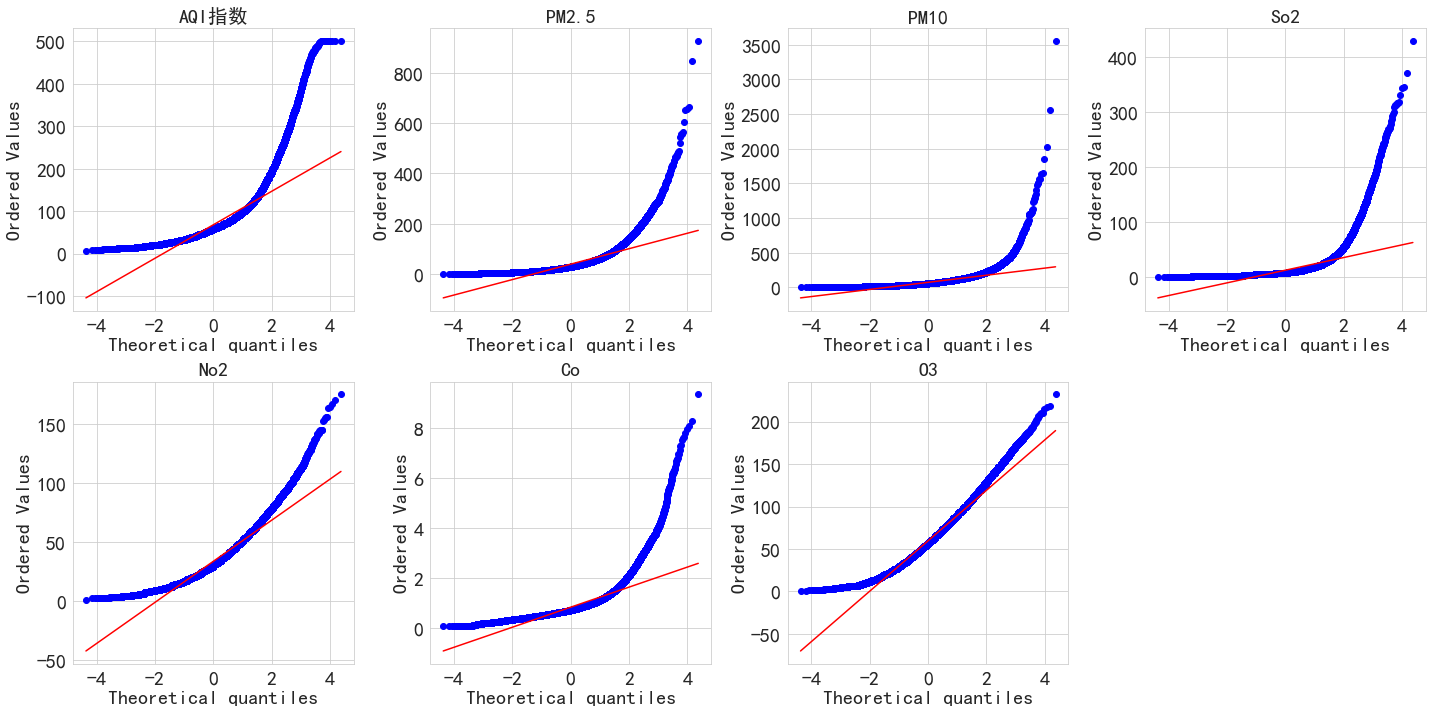

In [11]:
# 正态性检验
plt.figure(figsize=(20,10))
for i in range(len(pre_data.columns)):
    plt.subplot(2,4,i+1)
    sample_data=pre_data[pre_data.columns[i]]
    stats.probplot(sample_data,dist='norm',plot=plt)
    
    # 设置坐标轴标签和刻度字体大小
    plt.xlabel(plt.gca().get_xlabel(), fontsize=20)  # 增大x轴标签字体
    plt.ylabel(plt.gca().get_ylabel(), fontsize=20)  # 增大y轴标签字体
    
    plt.title(pre_data.columns[i], fontsize=20)
    # 增大刻度字体
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, '各指标间相关系数图')

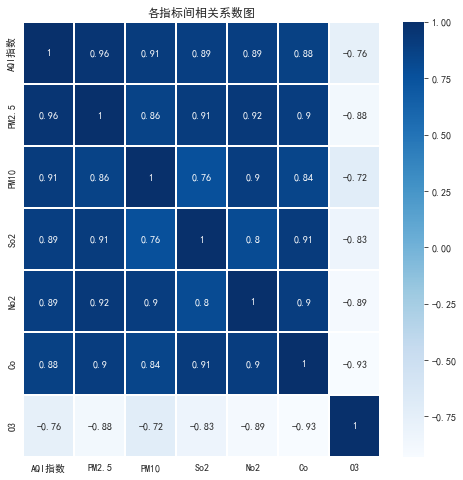

In [29]:
# 相关系数热力图
cor_data = all_data.iloc[:, ~all_data.columns.isin(['年','月','日','日期','当天AQI排名','质量等级','省份'])]
corr=temp.corr("spearman")
plt.figure(figsize=(8,8))
ax = sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns, 
                 linewidths=0.2,cmap="Blues",annot=True)
plt.title("各指标间相关系数图")

### 预测

In [30]:
pre_data=all_data.iloc[:, ~all_data.columns.isin(['年','月','日','日期','当天AQI排名','质量等级','省份'])]
pre_data

,AQI指数,PM2.5,PM10,So2,No2,Co,O3
0,64,31,77,23,33,0.65,23
1,83,59,99,27,37,0.92,24
2,95,70,118,43,43,1.15,20
3,130,98,160,46,47,1.16,29
4,186,146,194,39,44,1.44,17
...,...,...,...,...,...,...,...
111509,110,83,103,6,37,0.91,27
111510,105,79,97,6,38,0.89,31
111511,108,81,102,7,40,0.91,27
111512,108,81,103,7,37,0.87,31


#### 划分数据集

In [7]:
# 划分数据集
model_X=all_data.iloc[:, ~all_data.columns.isin(["AQI指数",'年','月','日','日期','当天AQI排名','质量等级','省份'])]
model_y=all_data[["质量等级"]]
level_mapping = {' 严重污染':0, ' 重度污染':1,' 中度污染':2, ' 轻度污染':3, ' 良':4, ' 优':5}
model_y["质量等级"] = model_y["质量等级"].map(level_mapping)
print("数据集抽样前规模",model_X.shape[0])
# 数据过抽样
model_smote=SMOTE()
model_X,model_y=model_smote.fit_resample(model_X,model_y)
# 划分训练集 测试集
X_train, X_test, y_train, y_test=model_selection.train_test_split(model_X, model_y,test_size=0.3)
print("数据集过抽样后规模：",model_X.shape[0])
print("训练集规模：",X_train.shape[0])
print("测试集规模：",X_test.shape[0])


数据集抽样前规模 111514
数据集过抽样后规模： 304176
训练集规模： 212923
测试集规模： 91253


#### 评估函数

In [54]:
# 评估函数
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
access_dict={}
def assess(model,y_test,y_pre,time):
    access_li=[]
    acc_s=accuracy_score(y_test,y_pre)
    f1_s = f1_score(y_test,y_pre,average='weighted')
    r2=r2_score(y_test, y_pre)
    mae = mean_absolute_error(y_test, y_pre)
    access_li=[acc_s,f1_s,r2,mae,time]
    if model not in access_dict:
        access_dict[model] = []
    for element in access_li:
        access_dict[model].append(element)
    print(model)
    print('准确率',"%.5f"%acc_s)
    print('F1度量',"%.5f"%f1_s)
    print('决定系数R2',"%.5f"%r2)
    print('平均绝对误差',"%.5f"%mae)

#### 基于统计检验（卡方检验）的特征选择

In [49]:
temp=all_data.drop(['质量等级','AQI指数','日期','年','月','日','当天AQI排名'], axis=1)
X=all_data.drop(['质量等级','AQI指数','日期','年','月','日'], axis=1).to_numpy()
feature_names = temp.columns.tolist()
y = all_data['质量等级'].tolist()

# 创建卡方特征选择器，选择前 2 个特征
selector = SelectKBest(score_func=chi2, k=4)
# 进行特征选择
selector.fit(X, y)

# 获取选择的特征索引
selected_indices = selector.get_support(indices=True)
# 根据索引获取选择的特征名称
selected_features = [feature_names[i] for i in selected_indices]

print("选择的特征:", selected_features)

选择的特征: ['PM2.5', 'PM10', 'So2', 'Co']


#### 随机森林

[(0.883, 'PM10'), (0.878, 'PM2.5'), (0.458, 'Co'), (0.427, 'No2'), (0.26, 'So2'), (0.1, 'O3')]


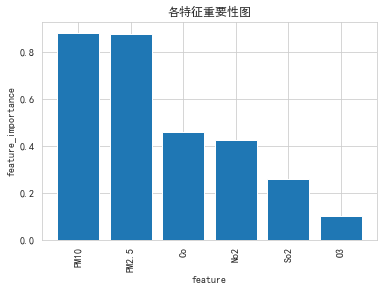

In [33]:
# 随机森林
X=pre_data.drop(['AQI指数'],axis=1)
y=pre_data['AQI指数']
names = X.columns
rf = RandomForestRegressor(n_estimators=50, max_depth=5)
# 5折交叉验证
kfold = KFold(n_splits=5, shuffle=True)
scores = []
for column in X.columns:
    tempx = X[column].values.reshape(-1, 1)
    score = cross_val_score(rf, tempx, y, scoring="r2",cv=kfold)
    scores.append((round(np.mean(score), 3), column))
    scores=sorted(scores, reverse=True)
print(scores)
x1=[]
y1=[]
for i in range(0,6):
    x1.append(scores[i][0])
    y1.append(scores[i][1])
plt.bar(y1,x1)
plt.xticks(rotation=90,fontsize=10)
plt.xlabel('feature')
plt.ylabel('feature_importance')
plt.title('各特征重要性图')
plt.show()

In [34]:
#### 选择最优分类器
rf_X = X_train[['PM10','PM2.5','Co','No2']]
parameters = {'n_estimators':range(50,200,50),
              'criterion':["gini", "entropy"],
             "max_depth":range(5,8)}
grid=GridSearchCV(RandomForestClassifier(),param_grid=parameters,cv=5,scoring="accuracy")
grid.fit(rf_X,y_train)
print("最优分类器：", grid.best_params_ ,"最优分数：", grid.best_score_)

最优分类器： {'criterion': 'entropy', 'max_depth': 7, 'n_estimators': 150} 最优分数： 0.9444306224606406


In [55]:
import time
rf_X = X_train[['PM10','PM2.5','Co','No2']]
start_time = time.time()

rfc = RandomForestClassifier(n_estimators=150,criterion="entropy",max_depth=7)
rfc.fit(rf_X, y_train)

training_time = time.time() - start_time
print(f"模型训练时间: {training_time:.2f} 秒")

rf_X_test = X_test[['PM10','PM2.5','Co','No2']]
rfc_pre=rfc.predict(rf_X_test)

assess('RandomForest', y_test, rfc_pre,training_time)

模型训练时间: 32.88 秒
RandomForest
准确率 0.94470
F1度量 0.94459
决定系数R2 0.98050
平均绝对误差 0.05584


#### XGBoost

In [38]:
X=pre_data.drop(['AQI指数'],axis=1)
y=pre_data['AQI指数']

model = XGBClassifier()
model.fit(X_test,y_test)
plot_importance(model)
plt.show()

<Figure size 1440x720 with 0 Axes>

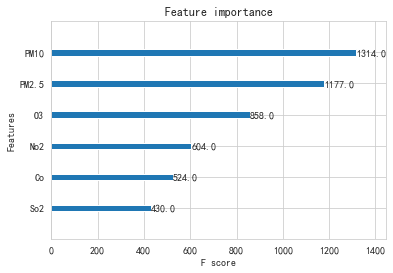

In [54]:
# xgboost
xgb1 = XGBRegressor()
xgb1.fit(X, y)
plt.figure(figsize=(20, 10))
plot_importance(xgb1)
plt.show()

In [39]:
#### 选取最优分类器
xgb_X = X_train[['PM10','PM2.5','O3']]
parameters = {'n_estimators':range(50,200,50),
             'max_depth':[*range(5,8)]}
grid=GridSearchCV(xgb.XGBClassifier(),param_grid=parameters,cv=5,scoring="accuracy")
grid.fit(xgb_X,y_train)
print("最优分类器：", grid.best_params_ ,"最优分数：", grid.best_score_)

最优分类器： {'max_depth': 7, 'n_estimators': 150} 最优分数： 0.9688619841794127


In [56]:
import xgboost as xgb
# XGBoost模型
xgb_X = X_train[['PM10','PM2.5','O3']]
xgb_X_test = X_test[['PM10','PM2.5','O3']]

start_time = time.time()

xgb=xgb.XGBClassifier(max_depth=7, n_estimators=150)
xgb.fit(xgb_X,y_train)

training_time = time.time() - start_time
print(f"模型训练时间: {training_time:.2f} 秒")

# 对测试集进行预测
xgb_pre = xgb.predict(xgb_X_test)


# 模型评估
assess('XGBoost', y_test, xgb_pre,training_time)

模型训练时间: 29.79 秒
XGBoost
准确率 0.96991
F1度量 0.96986
决定系数R2 0.98936
平均绝对误差 0.03041


#### LightGBM

In [42]:
X=pre_data.drop(['AQI指数'],axis=1)
y=pre_data['AQI指数']

In [45]:
## 基于交叉验证的特征选择
# 这种方法在不同特征子集上进行交叉验证，选择使模型性能最优的特征子集。
from itertools import combinations
model = lgb.LGBMClassifier(objective='multiclass')

# 所有特征组合
all_features = X.columns.tolist()
best_score = -float('inf')
best_features = None

# 遍历不同特征数量
for num_features in range(1, len(all_features) + 1):
    # 生成所有可能的特征组合
    for feature_combination in combinations(all_features, num_features):
        feature_combination = list(feature_combination)
        X_train_subset = X_train[feature_combination]
        # 交叉验证
        scores = cross_val_score(model, X_train_subset, y_train, cv=5)
        mean_score = scores.mean()
        if mean_score > best_score:
            best_score = mean_score
            best_features = feature_combination

print("最佳特征:", best_features)

[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000285 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 170338, number of used features: 1
[LightGBM] [Info] Start training from score -1.791044
[LightGBM] [Info] Start training from score -1.795842
[LightGBM] [Info] Start training from score -1.790480
[LightGBM] [Info] Start training from score -1.790340
[LightGBM] [Info] Start training from score -1.789074
[LightGBM] [Info] Start training from score -1.793793
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000402 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 1

[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000294 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 170339, number of used features: 1
[LightGBM] [Info] Start training from score -1.791014
[LightGBM] [Info] Start training from score -1.795813
[LightGBM] [Info] Start training from score -1.790486
[LightGBM] [Info] Start training from score -1.790381
[LightGBM] [Info] Start training from score -1.789115
[LightGBM] [Info] Start training from score -1.793763
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000267 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 1

[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000250 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 202
[LightGBM] [Info] Number of data points in the train set: 170338, number of used features: 1
[LightGBM] [Info] Start training from score -1.791044
[LightGBM] [Info] Start training from score -1.795842
[LightGBM] [Info] Start training from score -1.790516
[LightGBM] [Info] Start training from score -1.790340
[LightGBM] [Info] Start training from score -1.789074
[LightGBM] [Info] Start training from score -1.793757
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000325 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 203
[LightGBM] [Info] Number of data points in the train set: 1

[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000434 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 170339, number of used features: 2
[LightGBM] [Info] Start training from score -1.791014
[LightGBM] [Info] Start training from score -1.795813
[LightGBM] [Info] Start training from score -1.790486
[LightGBM] [Info] Start training from score -1.790381
[LightGBM] [Info] Start training from score -1.789115
[LightGBM] [Info] Start training from score -1.793763
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000475 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 425
[LightGBM] [Info] Number of data points in the train set: 1

[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000387 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 458
[LightGBM] [Info] Number of data points in the train set: 170338, number of used features: 2
[LightGBM] [Info] Start training from score -1.791044
[LightGBM] [Info] Start training from score -1.795842
[LightGBM] [Info] Start training from score -1.790516
[LightGBM] [Info] Start training from score -1.790340
[LightGBM] [Info] Start training from score -1.789074
[LightGBM] [Info] Start training from score -1.793757
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000507 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 455
[LightGBM] [Info] Number of data points in the train set: 1

...

[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000628 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 884
[LightGBM] [Info] Number of data points in the train set: 170338, number of used features: 4
[LightGBM] [Info] Start training from score -1.791044
[LightGBM] [Info] Start training from score -1.795842
[LightGBM] [Info] Start training from score -1.790480
[LightGBM] [Info] Start training from score -1.790340
[LightGBM] [Info] Start training from score -1.789074
[LightGBM] [Info] Start training from score -1.793793
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001945 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 882
[LightGBM] [Info] Number of data points in the train set: 170338, number of used features: 4
[LightGBM] [Info] Start traini

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001947 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 880
[LightGBM] [Info] Number of data points in the train set: 170339, number of used features: 4
[LightGBM] [Info] Start training from score -1.791014
[LightGBM] [Info] Start training from score -1.795813
[LightGBM] [Info] Start training from score -1.790486
[LightGBM] [Info] Start training from score -1.790381
[LightGBM] [Info] Start training from score -1.789115
[LightGBM] [Info] Start training from score -1.793763
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000600 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 883
[LightGBM] [Info] Number of data points in the train set: 170339, number of used features: 4
[LightGBM] [Info] Start traini

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002546 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1137
[LightGBM] [Info] Number of data points in the train set: 170338, number of used features: 5
[LightGBM] [Info] Start training from score -1.791044
[LightGBM] [Info] Start training from score -1.795842
[LightGBM] [Info] Start training from score -1.790516
[LightGBM] [Info] Start training from score -1.790340
[LightGBM] [Info] Start training from score -1.789074
[LightGBM] [Info] Start training from score -1.793757
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002414 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1137
[LightGBM] [Info] Number of data points in the train set: 170338, number of used features: 5
[LightGBM] [Info] Start training from score -1.791044
[LightGBM] [Info] Start training from 

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002574 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1139
[LightGBM] [Info] Number of data points in the train set: 170338, number of used features: 5
[LightGBM] [Info] Start training from score -1.791044
[LightGBM] [Info] Start training from score -1.795842
[LightGBM] [Info] Start training from score -1.790480
[LightGBM] [Info] Start training from score -1.790340
[LightGBM] [Info] Start training from score -1.789074
[LightGBM] [Info] Start training from score -1.793793
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002583 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1137
[LightGBM] [Info] Number of data points in the train set: 170338, number of used features: 5
[LightGBM] [Info] Start training from score -1.791044
[LightGBM] [Info] Start training from 

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002610 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1393
[LightGBM] [Info] Number of data points in the train set: 170339, number of used features: 6
[LightGBM] [Info] Start training from score -1.791014
[LightGBM] [Info] Start training from score -1.795813
[LightGBM] [Info] Start training from score -1.790486
[LightGBM] [Info] Start training from score -1.790381
[LightGBM] [Info] Start training from score -1.789115
[LightGBM] [Info] Start training from score -1.793763
最佳特征: ['PM2.5', 'PM10', 'So2', 'No2', 'Co', 'O3']


In [46]:
lgb_X=X_train[['PM2.5', 'PM10', 'No2', 'Co', 'O3','So2']]
# 定义LightGBM分类器
lgb_classifier = lgb.LGBMClassifier()

# 定义要搜索的超参数网格
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 4, 5]
}

# 创建GridSearchCV对象
grid_search = GridSearchCV(estimator=lgb_classifier, param_grid=param_grid, cv=5, scoring='accuracy')

# 执行网格搜索
grid_search.fit(lgb_X, y_train)

# 输出最优超参数组合
print("最优超参数组合:", grid_search.best_params_)
print("最优分数：", grid_search.best_score_)

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002356 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1394
[LightGBM] [Info] Number of data points in the train set: 170338, number of used features: 6
[LightGBM] [Info] Start training from score -1.791044
[LightGBM] [Info] Start training from score -1.795842
[LightGBM] [Info] Start training from score -1.790480
[LightGBM] [Info] Start training from score -1.790340
[LightGBM] [Info] Start training from score -1.789074
[LightGBM] [Info] Start training from score -1.793793
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002986 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1392
[LightGBM] [Info] Number of data points in the train set: 170338, number of used features: 6
[LightGBM] [Info] Start training from score -1.791044
[LightGBM] [Info] Start training from 

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003081 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1393
[LightGBM] [Info] Number of data points in the train set: 170339, number of used features: 6
[LightGBM] [Info] Start training from score -1.791014
[LightGBM] [Info] Start training from score -1.795813
[LightGBM] [Info] Start training from score -1.790486
[LightGBM] [Info] Start training from score -1.790381
[LightGBM] [Info] Start training from score -1.789115
[LightGBM] [Info] Start training from score -1.793763
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003124 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1394
[LightGBM] [Info] Number of data points in the train set: 170338, number of used features: 6
[LightGBM] [Info] Start training from score -1.791044
[LightGBM] [Info] Start training from 

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [57]:
lgb_X = X_train[['PM2.5', 'PM10', 'No2', 'Co', 'So2','O3']]
lgb_X_test = X_test[['PM2.5', 'PM10', 'No2', 'Co', 'So2', 'O3']]
start_time = time.time()
model = lgb.LGBMClassifier(learning_rate=0.2, max_depth=5, n_estimators=200)
model.fit(lgb_X, y_train)
training_time = time.time() - start_time
print(f"模型训练时间: {training_time:.2f} 秒")
lgb_pre=model.predict(lgb_X_test)
assess('LightGBM', y_test, lgb_pre,training_time)

[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003894 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1395
[LightGBM] [Info] Number of data points in the train set: 212923, number of used features: 6
[LightGBM] [Info] Start training from score -1.791032
[LightGBM] [Info] Start training from score -1.795830
[LightGBM] [Info] Start training from score -1.790497
[LightGBM] [Info] Start training from score -1.790356
[LightGBM] [Info] Start training from score -1.789091
[LightGBM] [Info] Start training from score -1.793767
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

#### LSTM

In [67]:
# 新增时间属性
for i in data_li:
    i['Date']=i['年'].map(str)+'-'+i['月'].map(str)+'-'+i['日'].map(str)
    # 确保时间的格式
    i['Date']=i['Date'].astype("datetime64") 

Epoch 1/50
288/288 [==============================] - 2s 3ms/step - loss: 1.6116 - accuracy: 0.3119 - val_loss: 1.3261 - val_accuracy: 0.5159
Epoch 2/50
288/288 [==============================] - 0s 2ms/step - loss: 1.0603 - accuracy: 0.6741 - val_loss: 0.8783 - val_accuracy: 0.7423
Epoch 3/50
288/288 [==============================] - 0s 2ms/step - loss: 0.7690 - accuracy: 0.7784 - val_loss: 0.6938 - val_accuracy: 0.7862
Epoch 4/50
288/288 [==============================] - 0s 2ms/step - loss: 0.6336 - accuracy: 0.8063 - val_loss: 0.5929 - val_accuracy: 0.8044
Epoch 5/50
288/288 [==============================] - 0s 2ms/step - loss: 0.5536 - accuracy: 0.8193 - val_loss: 0.5263 - val_accuracy: 0.8183
Epoch 6/50
288/288 [==============================] - 0s 2ms/step - loss: 0.5003 - accuracy: 0.8270 - val_loss: 0.4807 - val_accuracy: 0.8283
Epoch 7/50
288/288 [==============================] - 0s 2ms/step - loss: 0.4614 - accuracy: 0.8331 - val_loss: 0.4490 - val_accuracy: 0.8366
Epoch 

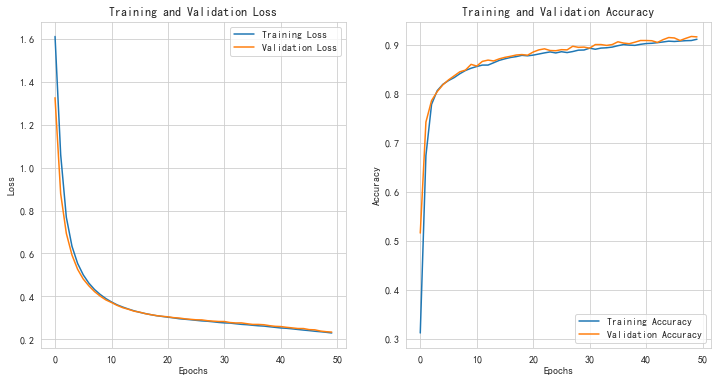

In [68]:
data1=data1[['质量等级','PM10','PM2.5','No2','Co']]
level_mapping = {' 严重污染':0, ' 重度污染':1,' 中度污染':2, ' 轻度污染':3, ' 良':4, ' 优':5}
data1["质量等级"] = data1["质量等级"].map(level_mapping)

df = pd.DataFrame(data1)
data = data1
X1=data[['PM10','PM2.5','No2','Co']]
y1=data[['质量等级']]
model_smote=SMOTE()
X1,y1=model_smote.fit_resample(X1,y1)
# 数据归一化
scaler = MinMaxScaler()
X1 = scaler.fit_transform(X1)
X1 = X1.reshape((X1.shape[0], 1, X1.shape[1]))

# 划分训练集和测试集
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# 构建 LSTM 模型
model = Sequential()
model.add(LSTM(50, input_shape=(X1_train.shape[1], X1_train.shape[2])))
# 六分类问题，输出层神经元个数
model.add(Dense(6, activation='softmax'))

# 编译模型
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 训练模型
start_time = time.time()

history = model.fit(X1_train, y1_train, epochs=50, batch_size=32, validation_data=(X1_test, y1_test))

training_time = time.time() - start_time
print(f"模型训练时间: {training_time:.2f} 秒")

# 进行预测
y_pred_probs = model.predict(X1_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 计算评估指标
assess('LSTM',y1_test,y_pred,training_time)
# 绘制拟合图
plt.figure(figsize=(12, 6))

# 绘制损失曲线
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# 绘制准确率曲线
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

#### 评估可视化

In [102]:
access_dict["ARIMA"] = [0.84239,0.83118,0.37094,0.16304,0]
access_dict

{'RandomForest': [0.9447031878403997,
  0.9445917564640118,
  0.9804971461384987,
  0.05584473935103503,
  32.87712740898132],
 'XGBoost': [0.9699078386464006,
  0.9698574246240708,
  0.9893631029824248,
  0.03040995912463152,
  29.78991198539734],
 'LightGBM': [0.9798910720743428,
  0.9798599968055434,
  0.9928824713783633,
  0.02032809880223116,
  4.494914293289185],
 'LSTM': [0.9161234245980009,
  0.915768933412353,
  0.9704857349679571,
  0.08387657540199914,
  24.05653953552246],
 'ARIMA': [0.84239, 0.83118, 0.37094, 0.16304, 0]}

In [110]:
access_dict

{'RandomForest': [0.9447031878403997,
  0.9445917564640118,
  0.9804971461384987,
  0.05584473935103503,
  32.87712740898132],
 'XGBoost': [0.9699078386464006,
  0.9698574246240708,
  0.9893631029824248,
  0.03040995912463152,
  29.78991198539734],
 'LightGBM': [0.9798910720743428,
  0.9798599968055434,
  0.9928824713783633,
  0.02032809880223116,
  4.494914293289185],
 'LSTM': [0.9161234245980009,
  0.915768933412353,
  0.9704857349679571,
  0.08387657540199914,
  24.05653953552246],
 'ARIMA': [0.84239, 0.83118, 0.37094, 0.16304, 0]}

In [10]:
access_dict={'RandomForest': [0.9447031878403997,
  0.9445917564640118,
  0.9804971461384987,
  0.05584473935103503,
  32.87712740898132],
 'XGBoost': [0.9699078386464006,
  0.9698574246240708,
  0.9893631029824248,
  0.03040995912463152,
  29.78991198539734],
 'LightGBM': [0.9798910720743428,
  0.9798599968055434,
  0.9928824713783633,
  0.02032809880223116,
  4.494914293289185],
 'LSTM': [0.9161234245980009,
  0.915768933412353,
  0.9704857349679571,
  0.08387657540199914,
  24.05653953552246],
 'ARIMA': [0.84239, 0.83118, 0.37094, 0.16304, 0]}

In [17]:
# 提取模型名称作为 x 轴数据
x_axis = list(access_dict.keys())

# 创建 Line 图表对象
line = (
    Line(init_opts=opts.InitOpts(theme=ThemeType.DARK))
    .add_xaxis(x_axis)
)
y_=["Accuracy","F1_score","R2","MAE","Time"]
line_colors = ["#FFA500", "#00FF00", "#00BFFF", "#FF69B4", "#9370DB"]
# 为每个指标添加 y 轴数据
for i in range(len(access_dict[x_axis[0]])):
    y_axis = [access_dict[model][i] for model in x_axis]
    line.add_yaxis(
        series_name=y_[i],
        y_axis=y_axis,
        label_opts=opts.LabelOpts(is_show=False),
        linestyle_opts=opts.LineStyleOpts(color=line_colors[i])
    )
# 设置全局配置项
line.set_global_opts(
    title_opts=opts.TitleOpts(title="Model Performance Comparison"),
    tooltip_opts=opts.TooltipOpts(trigger="axis"),
    xaxis_opts=opts.AxisOpts(name="Model"),
    yaxis_opts=opts.AxisOpts(name="Value"),
    legend_opts=opts.LegendOpts(pos_top="5%")
)

line.render_notebook()